In [1]:
import _referAsMain
import sys; print(sys.version_info)
from datasets import load_dataset
import torch, random, time, math
from IPython.display import SVG, display

added '/home/time/Bureau/pfe/PFE_LLM_art_generation' to import paths
sys.version_info(major=3, minor=10, micro=19, releaselevel='final', serial=0)


/home/time/Bureau/pfe/PFE_LLM_art_generation/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import torch

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)
print("Device count:", torch.cuda.device_count())

Torch version: 2.9.1+cu128
CUDA available: True
CUDA version: 12.8
Device count: 1


In [3]:
# Load Alpaca format
dataset = load_dataset("xingxm/SVGX-SFT-1M", split="train", data_files="SVGX_SFT_GEN_51k.json")

In [4]:
print(len(dataset))

514172


In [5]:
print(f"{dataset.size_in_bytes:_d}")

2_346_931_760


In [6]:
print(dataset[0])

{'instruction': 'Generate an SVG illustration from the given description.', 'input': 'SVG illustration of person in suit levitating.', 'output': '<svg enable-background="new 0 0 128 128" viewBox="0 0 128 128" xmlns="http://www.w3.org/2000/svg" xmlns:xlink="http://www.w3.org/1999/xlink"><radialGradient id="a" cx="63.9995" cy="8.0164" gradientTransform="matrix(1 0 0 -.305 0 122.4395)" gradientUnits="userSpaceOnUse" r="15.2017"><stop offset=".1396" stop-color="#504f4f" stop-opacity=".8"/><stop offset=".8722" stop-color="#616161" stop-opacity="0"/></radialGradient><radialGradient id="b" cx="108.9787" cy="96.3683" gradientTransform="matrix(1 0 0 .5046 -39.7364 -17.1289)" gradientUnits="userSpaceOnUse" r="8.3693"><stop offset=".7275" stop-color="#6d4c41" stop-opacity="0"/><stop offset="1" stop-color="#6d4c41"/></radialGradient><radialGradient id="c" cx="100.7358" cy="97.6126" gradientTransform="matrix(-.9057 .4354 -.3144 -.6903 199.4155 53.7455)" gradientUnits="userSpaceOnUse" r="2.4733"><st

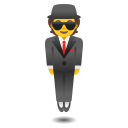

In [7]:
display(SVG(data=dataset[0]["output"]))

In [8]:
import LLM.nanochat.gpt as nanoChatModel
import LLM.nanochat.tokenizer as tokenizerLib
from LLM.nanochat.common import compute_init, autodetect_device_type

In [9]:
device_type = "cuda"
device_type = (autodetect_device_type() if device_type == "" else device_type)
ddp, ddp_rank, ddp_local_rank, ddp_world_size, device = compute_init(device_type)

2026-02-13 19:45:05,581 - LLM.nanochat.common - INFO - Distributed world size: 1


In [10]:
tokenizerPreTrained = tokenizerLib.HuggingFaceTokenizer.from_pretrained("gpt2")
#tokenizerPreTrained = tokenizerLib.HuggingFaceTokenizer.from_pretrained("xlnet/xlnet-base-cased")

2026-02-13 19:45:13,648 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/gpt2/resolve/main/tokenizer.json "HTTP/1.1 200 OK"
2026-02-13 19:45:13,772 - httpx - INFO - HTTP Request: GET https://huggingface.co/gpt2/resolve/main/tokenizer.json "HTTP/1.1 200 OK"
2026-02-13 19:45:13,773 - huggingface_hub.utils._http - WARNING - Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.


In [11]:
tokenizerTrainedSmallest = tokenizerLib.HuggingFaceTokenizer.train_from_iterator(
    dataset[: 100]["output"], vocab_size=2048)

In [12]:
tokenizerTrainedSmall = tokenizerLib.HuggingFaceTokenizer.train_from_iterator(
    dataset[: 5_000]["output"], vocab_size=2048)

In [13]:
tokenizerTrainedMedium = tokenizerLib.HuggingFaceTokenizer.train_from_iterator(
    dataset[: 25_000]["output"], vocab_size=2048)

In [ ]:
tokenizerTrained = tokenizerLib.HuggingFaceTokenizer.train_from_iterator(
    dataset[: 100_000]["output"], vocab_size=2048)

In [ ]:
tokenizerTrainedLarge = tokenizerLib.HuggingFaceTokenizer.train_from_iterator(
    dataset[: 3_000_000]["output"], vocab_size=2048*2)

In [ ]:
tokenizerTrainedLargest = tokenizerLib.HuggingFaceTokenizer.train_from_iterator(
    dataset[: 15_000_000]["output"], vocab_size=2048*2)

In [14]:
tokenizer = tokenizerTrainedMedium
vocab_size = tokenizer.get_vocab_size()
print(vocab_size)
display(sorted([(id, tk) for tk, id in tokenizer.tokenizer.get_vocab().items()], reverse=False))
OutStart_Token = "<|output_start|>"
OutEnd_Token = "<|output_end|>"
OutEnd_ids = tokenizer.encode(OutEnd_Token); assert len(OutEnd_ids) == 1
OutEnd_id = OutEnd_ids[0]; del OutEnd_ids

1705


[(0, '<|bos|>'),
 (1, '<|user_start|>'),
 (2, '<|user_end|>'),
 (3, '<|assistant_start|>'),
 (4, '<|assistant_end|>'),
 (5, '<|python_start|>'),
 (6, '<|python_end|>'),
 (7, '<|output_start|>'),
 (8, '<|output_end|>'),
 (9, '!'),
 (10, '"'),
 (11, '#'),
 (12, '$'),
 (13, '%'),
 (14, '&'),
 (15, "'"),
 (16, '('),
 (17, ')'),
 (18, '*'),
 (19, '+'),
 (20, ','),
 (21, '-'),
 (22, '.'),
 (23, '/'),
 (24, '0'),
 (25, '1'),
 (26, '2'),
 (27, '3'),
 (28, '4'),
 (29, '5'),
 (30, '6'),
 (31, '7'),
 (32, '8'),
 (33, '9'),
 (34, ':'),
 (35, ';'),
 (36, '<'),
 (37, '='),
 (38, '>'),
 (39, '?'),
 (40, '@'),
 (41, 'A'),
 (42, 'B'),
 (43, 'C'),
 (44, 'D'),
 (45, 'E'),
 (46, 'F'),
 (47, 'G'),
 (48, 'H'),
 (49, 'I'),
 (50, 'J'),
 (51, 'K'),
 (52, 'L'),
 (53, 'M'),
 (54, 'N'),
 (55, 'O'),
 (56, 'P'),
 (57, 'Q'),
 (58, 'R'),
 (59, 'S'),
 (60, 'T'),
 (61, 'U'),
 (62, 'V'),
 (63, 'W'),
 (64, 'X'),
 (65, 'Y'),
 (66, 'Z'),
 (67, '['),
 (68, '\\'),
 (69, ']'),
 (70, '^'),
 (71, '_'),
 (72, '`'),
 (73, 'a'),
 

In [15]:
aspect_ratio = 10.5
head_dim = 128
max_seq_len = 2048*8
window_pattern = "SSSL"

def build_model_meta(depth):
    """Build a model on meta device for a given depth (shapes/dtypes only, no data)."""
    # Model dim is nudged up to nearest multiple of head_dim for clean division
    # (FA3 requires head_dim divisible by 8, and this guarantees head_dim == args.head_dim exactly)
    base_dim = depth * aspect_ratio
    model_dim = int(((base_dim + head_dim - 1) // head_dim) * head_dim)
    num_heads = int(model_dim // head_dim)
    config = nanoChatModel.GPTConfig(
        sequence_len=max_seq_len, vocab_size=vocab_size,
        n_layer=depth, n_head=num_heads, n_kv_head=num_heads, n_embd=model_dim,
        window_pattern=window_pattern,
    )
    print(config)
    with torch.device("meta"):
        model_meta = nanoChatModel.GPT(config)
    return model_meta

model = build_model_meta(6)
model.to_empty(device=device) # 2) All tensors get storage on target device but with uninitialized (garbage) data
model.init_weights() # 3) All tensors get initialized
optimizer = model.setup_optimizer()

params = model.num_scaling_params(); print(params.items())
params_Embed = (params['wte'] + params['value_embeds'])
print(f"{params['total']:_d} params "
      f"(with embeding: {params_Embed:_d} | "
      f"last layer: {params['lm_head']:_d} | "
      f"transformer: {params['transformer_matrices']:_d})"
    )
model = model.bfloat16()

model = torch.compile(model, dynamic=False) # the inputs to model will never change shape so dynamic=False is safe
#model.eval();


GPTConfig(sequence_len=16384, vocab_size=1705, n_layer=6, n_head=1, n_kv_head=1, n_embd=128, window_pattern='SSSL')
Padding vocab_size from 1705 to 1728 for efficiency
Scaling the LR for the AdamW parameters ∝1/√(128/768) = 2.449490
dict_items([('wte', 221184), ('value_embeds', 663552), ('lm_head', 221184), ('transformer_matrices', 1179744), ('scalars', 12), ('total', 2285676)])
2_285_676 params (with embeding: 884_736 | last layer: 221_184 | transformer: 1_179_744)


In [16]:
svg = dataset[-57]["output"]
encoded = tokenizer.tokenizer.encode(svg)
print(f"{len(svg):_d}, {len(encoded.ids):_d}")
print(encoded.ids)
print(" ".join(encoded.tokens))

16_623, 11_669
[484, 501, 266, 276, 32, 10, 490, 266, 24, 229, 24, 229, 276, 32, 229, 276, 32, 10, 499, 266, 276, 32, 10, 472, 266, 474, 468, 473, 465, 27, 475, 23, 296, 268, 483, 406, 281, 282, 266, 85, 229, 342, 22, 334, 229, 328, 22, 307, 267, 265, 24, 22, 297, 229, 24, 265, 24, 22, 319, 265, 24, 22, 284, 265, 24, 22, 328, 265, 24, 22, 298, 265, 24, 22, 373, 265, 24, 22, 312, 265, 26, 22, 276, 229, 24, 22, 381, 265, 25, 22, 404, 229, 24, 22, 298, 229, 24, 22, 306, 265, 24, 22, 376, 229, 29, 22, 404, 265, 292, 22, 320, 229, 316, 22, 373, 265, 305, 22, 332, 564, 229, 25, 22, 328, 229, 25, 22, 328, 229, 24, 229, 25, 22, 268, 229, 25, 22, 268, 229, 24, 22, 389, 229, 26, 22, 362, 267, 265, 292, 22, 336, 229, 28, 22, 350, 265, 296, 22, 362, 229, 295, 22, 327, 265, 296, 22, 381, 229, 295, 22, 357, 564, 229, 25, 22, 328, 229, 25, 22, 328, 229, 24, 229, 24, 229, 25, 22, 268, 265, 25, 22, 339, 229, 25, 22, 268, 10, 288, 279, 958, 382, 272, 281, 282, 266, 85, 229, 389, 22, 364, 229, 311, 22, 3

In [17]:
def show(gen):
    results = []
    memStart = torch.cuda.memory.memory_reserved()
    for nb, token in enumerate(gen):
        decoded = tokenizer.decode([token])
        results.append(decoded)
        #print(decoded, end="", flush=True)
        print(nb, end="\r", flush=True)
        if token == OutEnd_id:
            break
        memCurr = torch.cuda.memory.memory_reserved()
        if (memCurr-memStart) > 2 * 1e9: # using ..Go
            torch.cuda.memory.empty_cache()
            
    torch.cuda.memory.empty_cache()
    print()
    return results

In [18]:
torch.cuda.memory.empty_cache()
inputs_text = (dataset[0]["input"] * 1) + OutStart_Token
#inputs_text =  "SVG of a brick." + OutStart_Token
tokens = tokenizer.encode(inputs_text)
print(f"nb tokens in the input: {len(tokens):_d}")

print(inputs_text)
nbToGen = 100
tStart = time.perf_counter()
with torch.device(device):
    generated = show(model.generate(
        tokens=tokens, max_tokens=nbToGen, 
        temperature=1, top_k=None, seed=random.randint(0, 10_000)))
tTaken = (time.perf_counter() - tStart)
print(f'took: {tTaken:.2f} sec, ({len(generated)/tTaken:.2f} token/sec)')
print(inputs_text + "".join(generated))

nb tokens in the input: 30
SVG illustration of person in suit levitating.<|output_start|>
99
took: 0.73 sec, (137.34 token/sec)
SVG illustration of person in suit levitating.<|output_start|>ebebecdedfddodeei xmlnsshaebeaefcbbece?fadfbcdcbbf eaedfffdedcbcfafafa�EF-reebfffca<|assistant_start|>haBadcefeae Pixdaeafaeefffefalip-t83eaafeaeECECffdabdbedfnUsefaeffecbbebebeth kectebefffff)">
rotatfdffff�ebfdfaf	acbbfffbbeabloodgle61sRGBnoffedcdbeb="(# viewBoxefb�acfcee��� eebfaaedccaadd�hadowfcebcdectebc53ffdaaffebeefffcfdffbdbabcAfcbf style08ffcbacffebaedada


In [22]:
torch.cuda.memory.empty_cache()
start = 0
nbToGen = 100
tStart = time.perf_counter()
model.train()
lossEmaCoeff = 1/50

nb = 0
try:
    emaLoss = float("nan")
    samples = dataset[start: start+nbToGen]
    for nb, (input_text, output_text) in enumerate(zip(samples["input"], samples["output"])):
        tokens = tokenizer.encode(input_text + OutStart_Token + output_text + OutEnd_Token*2)
        tokens = tokens[: model.config.sequence_len//2]
        ids = torch.tensor([tokens], dtype=torch.long, device=device) # add batch dim
        with torch.device(device):
            loss = model.forward(ids[:, : -1], ids[:, 1: ])
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        loss = loss.detach().item()
        if math.isnan(emaLoss):
            emaLoss = loss
        else: emaLoss = (emaLoss * (1-lossEmaCoeff) + (loss * lossEmaCoeff))
        torch.cuda.memory.empty_cache()
        print(f"trained on input n°{start+nb}: {len(tokens):_d} tokens, loss: {loss:.4g}, emaLoss: {emaLoss:.4g}")
finally:
    tTaken = (time.perf_counter() - tStart)
    print(f'took: {tTaken:.2f} sec, ({(nb+1)/tTaken:.2f} samples/sec)')
    print(f"new start at: {start + nb}")

trained on input n°0: 6_964 tokens, loss: 1.676, emaLoss: 1.676
trained on input n°1: 7_030 tokens, loss: 1.625, emaLoss: 1.675
trained on input n°2: 1_184 tokens, loss: 1.576, emaLoss: 1.673
trained on input n°3: 1_266 tokens, loss: 1.523, emaLoss: 1.67
trained on input n°4: 2_655 tokens, loss: 1.961, emaLoss: 1.676
trained on input n°5: 2_707 tokens, loss: 1.896, emaLoss: 1.68
trained on input n°6: 4_460 tokens, loss: 1.751, emaLoss: 1.682
trained on input n°7: 4_541 tokens, loss: 1.74, emaLoss: 1.683
trained on input n°8: 2_225 tokens, loss: 1.862, emaLoss: 1.686
trained on input n°9: 2_267 tokens, loss: 1.78, emaLoss: 1.688
trained on input n°10: 3_160 tokens, loss: 1.741, emaLoss: 1.689
trained on input n°11: 3_203 tokens, loss: 1.724, emaLoss: 1.69
trained on input n°12: 2_601 tokens, loss: 1.748, emaLoss: 1.691
trained on input n°13: 2_652 tokens, loss: 1.736, emaLoss: 1.692
trained on input n°14: 1_475 tokens, loss: 1.822, emaLoss: 1.695
trained on input n°15: 1_515 tokens, los

In [23]:
# a b c d e <start> f g h <end>
# b c d e <start> f g h <end> <end>

In [25]:
nb = 1000
totalTokens = sum(len(tokenizerTrainedMedium.encode(line)) for line in dataset[-nb: ]["output"])
nbChars = sum(len(line) for line in dataset[-nb: ]["output"])
print(f"estimated outputChars/tokens: {nbChars/totalTokens:.2f}")
print(f"estimated tokens/output: {totalTokens/nb:.2f}")
print(f"estimated chars/output: {nbChars/nb:.2f}")

estimated outputChars/tokens: 1.46
estimated tokens/output: 3794.28
estimated chars/output: 5546.09
